In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(source='local', symbol='BTCUSDC')
raw

,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:25,89139.601562,89140.203125,89139.601562,89140.203125,0.012,0.002,0.002,0.000,1.000000,...,0.821,0.006,0.139,0.112,0.002,0.139,0.002,0.056,0.141,0.002
1,2026-01-23 11:50:30,89140.101562,89140.101562,89139.601562,89139.601562,0.074,0.006,0.006,0.000,1.000000,...,0.002,0.005,0.141,1.796,0.550,0.062,0.139,0.002,0.139,0.014
2,2026-01-23 11:50:35,89139.500000,89139.500000,89130.500000,89130.500000,0.769,0.569,0.000,0.569,-1.000000,...,0.002,0.139,0.744,0.112,0.139,1.010,1.796,0.139,0.112,1.139
3,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.569,0.000,0.569,-1.000000,...,1.094,0.139,1.122,1.796,0.139,1.002,0.112,1.139,0.179,0.142
4,2026-01-23 11:50:45,89130.398438,89130.398438,89130.398438,89130.398438,0.004,0.569,0.000,0.569,-1.000000,...,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307,0.244,0.142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208997,2026-02-05 09:59:40,71412.703125,71412.796875,71412.703125,71412.796875,0.096,0.397,0.397,0.000,1.000000,...,0.003,0.058,0.354,0.011,0.002,0.038,0.002,0.002,0.005,0.336
208998,2026-02-05 09:59:45,71415.000000,71415.101562,71408.398438,71411.296875,0.487,0.173,0.166,0.007,0.919075,...,0.336,0.335,0.033,0.002,0.005,0.050,0.300,0.002,0.495,0.176
208999,2026-02-05 09:59:50,71413.000000,71415.000000,71411.101562,71411.101562,0.212,0.253,0.253,0.000,1.000000,...,0.002,0.005,0.250,0.002,0.532,0.176,0.629,0.839,0.050,0.052
209000,2026-02-05 09:59:55,71413.000000,71413.101562,71413.000000,71413.101562,0.103,0.007,0.000,0.007,-1.000000,...,0.532,0.176,0.838,0.839,0.002,0.036,0.003,0.354,0.011,0.002


In [16]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread
    return pd.Series(target, index=df.index)

In [17]:
target = calculate_spread_target(raw)

100%|██████████| 209001/209001 [00:01<00:00, 162514.55it/s]


# MAIN

In [213]:
import inspect
import importlib.util
from tqdm import tqdm

spec = importlib.util.spec_from_file_location("nn_features", "src/mlcore/features/nn_features.py")
test_features = importlib.util.module_from_spec(spec)
spec.loader.exec_module(test_features)

feature_functions = {
    name: func
    for name, func in inspect.getmembers(test_features, inspect.isfunction)
}


f_dict = {
    'target': target
}
for name, func in tqdm(feature_functions.items()):
    try:
        # print(name)
        f_dict[name] = func(raw)
    except Exception as e:
        print(f"  → ERROR in {name}: {str(e)}")

df = pd.DataFrame(f_dict)
df.dropna(inplace=True)
df

100%|██████████| 54/54 [00:01<00:00, 48.59it/s] 


,target,spread_acceleration_5,spread_acceleration_std_5,spread_atr_14,spread_atr_ratio_14,spread_buy_sell_volume_imbalance_10,spread_cubed,spread_current,spread_distance_to_max_10,spread_distance_to_min_10,...,spread_std_ratio_5_15,spread_volume_correlation_10,spread_volume_ratio_5_15,spread_volume_regime,spread_volume_spike_10,spread_volume_weighted_10,spread_volume_weighted_std_10,spread_vwap_deviation_10,spread_vwap_deviation_std_10,spread_zscore_10
0,0.500000,0.000000,0.000000,0.000000,1.000000,1.000000,0.217692,0.601562,0.000000,0.000000,...,1.000000,0.000000,1.000000,0.0,0.0,0.601563,1.086381e-08,4.530022e-06,0.000000,0.000000
1,9.000000,-0.050781,0.071816,0.000000,1.000000,-0.600000,0.125000,0.500000,0.101562,0.000000,...,1.000000,0.000000,1.000000,1.0,0.0,0.514172,1.314568e-02,-4.520424e-07,0.000007,-0.707107
2,0.000000,2.833333,4.995691,0.000000,1.000000,-0.908969,729.000000,9.000000,0.000000,8.500000,...,1.000000,0.996454,1.000000,1.0,0.0,8.146455,8.094917e-01,-2.980831e-05,0.000051,1.154638
3,0.000000,-2.250000,10.954408,0.000000,1.000000,-0.952201,0.000000,0.000000,9.000000,0.000000,...,1.000000,0.996942,1.000000,0.0,0.0,8.127443,8.988339e-01,-3.950927e-05,0.000046,-0.583985
4,2.296875,0.000000,10.738333,0.000000,1.000000,-0.947302,0.000000,0.000000,9.000000,0.000000,...,1.000000,0.997155,1.000000,0.0,0.0,8.089685,1.052702e+00,-3.160499e-05,0.000044,-0.516488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208997,6.703125,-0.560937,5.677345,10.435665,111.313758,0.083458,0.000824,0.093750,18.304688,0.000000,...,1.170526,0.678765,1.311305,0.0,0.0,12.831826,3.707652e+00,-2.841788e-06,0.000115,-1.713095
208998,3.898438,0.101562,6.656571,10.169055,1.517062,0.140108,301.184052,6.703125,10.101562,6.609375,...,0.930681,0.738355,0.875917,0.0,0.0,11.971606,3.486542e+00,1.367023e-05,0.000099,-0.453347
208999,0.101562,-0.179688,7.099813,9.721154,2.493603,0.177408,59.247730,3.898438,12.906250,3.804688,...,0.630512,0.781316,0.424366,0.0,0.0,12.015266,3.603497e+00,1.192729e-05,0.000099,-0.834713
209000,13.796875,0.059375,7.035135,9.169643,90.285712,0.129019,0.001048,0.101562,15.101562,0.007812,...,0.461813,0.908594,0.168338,0.0,0.0,11.373492,3.718571e+00,2.766005e-06,0.000092,-1.285599


In [214]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_regression

t = df['target'] 
result = []

for col in tqdm(df.columns):
    if col not in ['price', 'target']:
        feature = df[col]
        
        # Pearson correlation (линейная связь)
        corr, p_value = pearsonr(feature, t)
        
        # Information Coefficient = Spearman (ранговая корреляция)
        ic_spearman, _ = spearmanr(feature, t)

        try:
            # Mutual Information для регрессии
            mi = mutual_info_regression(
                feature.values.reshape(-1, 1), 
                t.values, 
                discrete_features=False, 
                random_state=42
            )
        except Exception as e:
            mi = [np.nan]

        result.append({
            'feature': col,
            "corr": corr,          
            'p_value': p_value,
            'mi': mi[0],           
            'ic': ic_spearman,     
        })

result = pd.DataFrame(result)
result = result.sort_values('corr', key=abs, ascending=False)
result

100%|██████████| 55/55 [00:38<00:00,  1.42it/s]


,feature,corr,p_value,mi,ic
11,spread_ema_8,0.726440,0.000000e+00,0.393358,0.729576
9,spread_ema_15,0.725767,0.000000e+00,0.409374,0.737560
2,spread_atr_14,0.718967,0.000000e+00,0.408339,0.738865
10,spread_ema_3,0.705839,0.000000e+00,0.349506,0.697663
33,spread_parkinson_10,0.705563,0.000000e+00,0.376534,0.715109
36,spread_quantile_90_15,0.691598,0.000000e+00,0.373175,0.707332
35,spread_quantile_10_15,0.673036,0.000000e+00,0.352480,0.698132
25,spread_min_5,0.662255,0.000000e+00,0.300560,0.656736
22,spread_max_5,0.659351,0.000000e+00,0.309656,0.662071
49,spread_volume_weighted_10,0.654594,0.000000e+00,0.301800,0.661221


In [215]:
for row in result.iterrows():
    print(row)

(11, feature    spread_ema_8
corr            0.72644
p_value             0.0
mi             0.393358
ic             0.729576
Name: 11, dtype: object)
(9, feature    spread_ema_15
corr            0.725767
p_value              0.0
mi              0.409374
ic               0.73756
Name: 9, dtype: object)
(2, feature    spread_atr_14
corr            0.718967
p_value              0.0
mi              0.408339
ic              0.738865
Name: 2, dtype: object)
(10, feature    spread_ema_3
corr           0.705839
p_value             0.0
mi             0.349506
ic             0.697663
Name: 10, dtype: object)
(33, feature    spread_parkinson_10
corr                  0.705563
p_value                    0.0
mi                    0.376534
ic                    0.715109
Name: 33, dtype: object)
(36, feature    spread_quantile_90_15
corr                    0.691598
p_value                      0.0
mi                      0.373175
ic                      0.707332
Name: 36, dtype: object)
(35, feature  

### XGBoost

In [216]:
feature_columns = [col for col in df.columns if col not in ['price', 'target']]
X = df[feature_columns].copy()
y = df['target'].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [217]:
# import numpy as np

# # Проверка на inf
# print("inf in X_train:", np.isinf(X_train).any())
# print("inf in y_train:", np.isinf(y_train).any())
# print("inf in X_test:", np.isinf(X_test).any())
# print("inf in y_test:", np.isinf(y_test).any())

# # Проверка на NaN
# print("nan in X_train:", np.isnan(X_train).any())
# print("nan in y_train:", np.isnan(y_train).any())

In [218]:
# df.drop(columns=['price_impact_asymmetry'], inplace=True)

In [219]:
from src.mlcore.train import train_regression_model

model = train_regression_model(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_estimators=5000,
    objective='reg:squarederror',
    max_depth=2,
)

Обучение модели...
[0]	validation_0-rmse:24.03413
[50]	validation_0-rmse:20.22443
[100]	validation_0-rmse:18.34805
[150]	validation_0-rmse:17.51401
[200]	validation_0-rmse:17.16626
[250]	validation_0-rmse:17.02233
[300]	validation_0-rmse:16.96830
[350]	validation_0-rmse:16.94164
[400]	validation_0-rmse:16.93314
[450]	validation_0-rmse:16.92857
[500]	validation_0-rmse:16.92626
[550]	validation_0-rmse:16.92214
[600]	validation_0-rmse:16.91572
[650]	validation_0-rmse:16.91080
[700]	validation_0-rmse:16.90552
[750]	validation_0-rmse:16.90047
[800]	validation_0-rmse:16.89587
[850]	validation_0-rmse:16.89158
[900]	validation_0-rmse:16.88894
[950]	validation_0-rmse:16.88477
[1000]	validation_0-rmse:16.88184
[1050]	validation_0-rmse:16.87965
[1100]	validation_0-rmse:16.87857
[1150]	validation_0-rmse:16.87450
[1200]	validation_0-rmse:16.87215
[1250]	validation_0-rmse:16.86957
[1300]	validation_0-rmse:16.86787
[1350]	validation_0-rmse:16.86578
[1393]	validation_0-rmse:16.86567
Модель сохранена в

MAE                      : 11.184302
RMSE                     : 16.865323
R²                       : 0.438407
MAE / mean|Δ|            : 0.453022
RMSE / RMSE_base         : 0.504851
mean|Δ| (target)         : 24.688232

------------------------------------------------------------
Directional Accuracy     : 0.977393
Target Pos Ratio         : 0.977393
Profit Factor            : 1031992796874999.875000
Avg Gain (correct)       : 25.259272
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9759, 0.9789)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
         quantile  confidence  directional_acc  mean_return  n_samples
(44.856, 211.396]   56.454666         1.000000    55.995453       4180
  (36.86, 44.856]   40.652458         1.000000    42.350284       4180
  (29.287, 36.86]   32.891525         0.999522    34.031689       

/Users/honeysuckle/dev/AlgoTradingSystem_v13.0/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


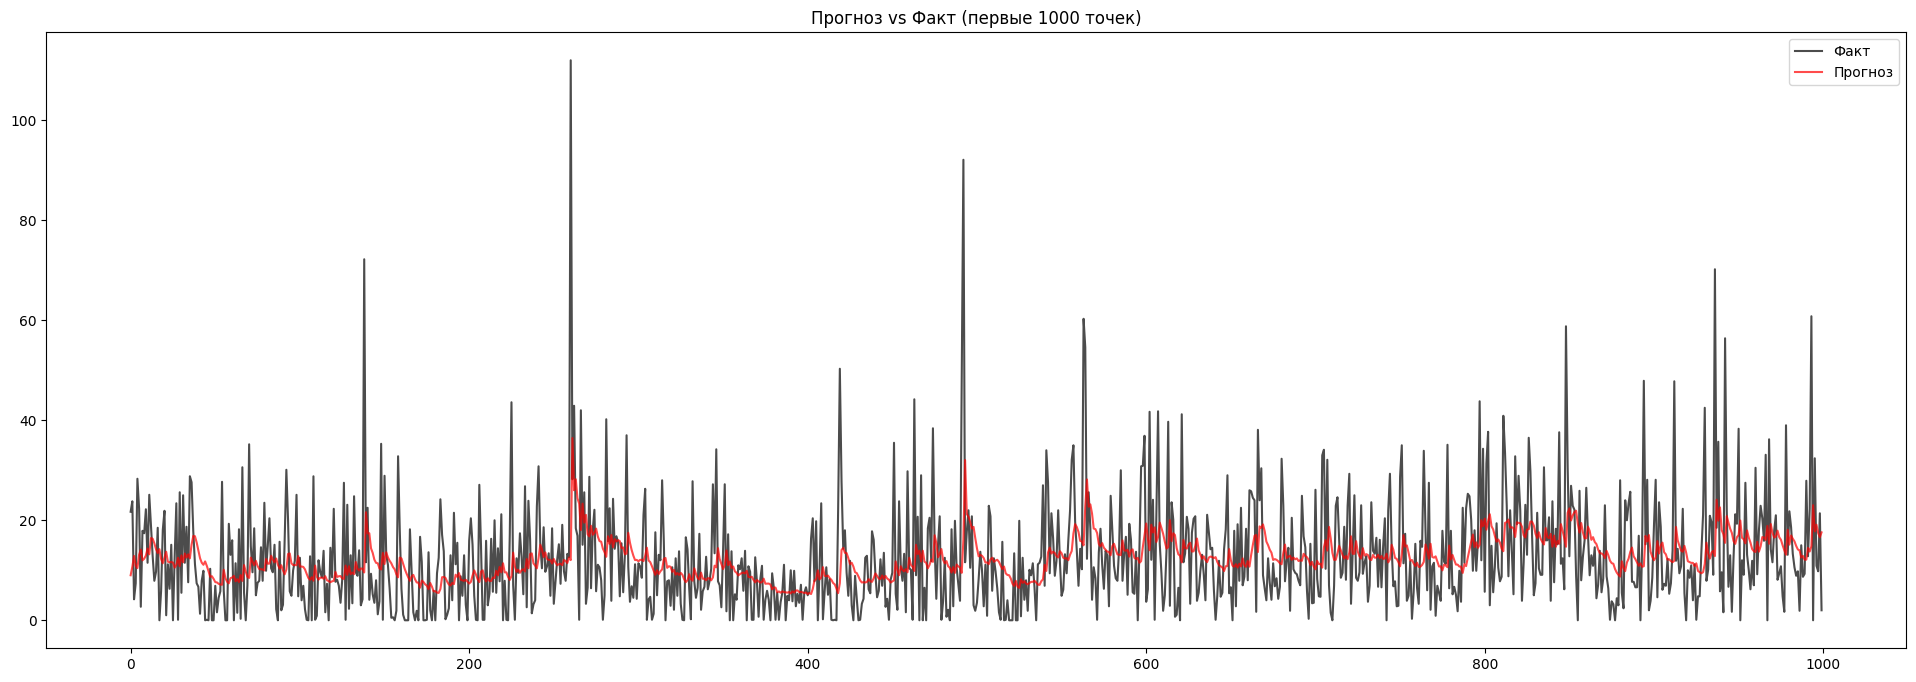

In [221]:
from src.mlcore.evaluation import evaluate_regression_model

y_pred = model.predict(X_test)

evaluate_regression_model(
    y_test=y_test,
    y_pred=y_pred,
    length=1000,
)

In [222]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Важности фичей")
for i in range(len(importance_df)):
    print(f"{importance_df.iloc[i]['importance']:.4f} | {importance_df.iloc[i]['feature']}")

Важности фичей
0.3790 | spread_ema_15
0.1879 | spread_ema_8
0.0732 | spread_atr_14
0.0546 | spread_ema_3
0.0405 | spread_min_5
0.0318 | spread_parkinson_10
0.0199 | spread_log
0.0149 | spread_current
0.0147 | spread_flow_volume_interaction_10
0.0137 | spread_cubed
0.0124 | spread_volume_weighted_10
0.0112 | spread_volume_weighted_std_10
0.0103 | spread_acceleration_std_5
0.0100 | spread_buy_sell_volume_imbalance_10
0.0098 | spread_ema_ratio_3_8
0.0084 | spread_log_diff_3
0.0076 | spread_max_5
0.0063 | spread_flow_imbalance_10
0.0063 | spread_std_15
0.0063 | spread_range_10
0.0059 | spread_quantile_10_15
0.0058 | spread_ema_ratio_8_15
0.0053 | spread_atr_ratio_14
0.0048 | spread_std_5
0.0043 | spread_min_20
0.0042 | spread_orderbook_depth_ratio
0.0039 | spread_vwap_deviation_10
0.0036 | spread_distance_to_min_10
0.0033 | spread_momentum_std_8
0.0032 | spread_regime_acceleration
0.0032 | spread_momentum_8
0.0031 | spread_normalized_range_15
0.0030 | spread_zscore_10
0.0027 | spread_order